# Phân loại Bệnh tiểu đường Pima Indians

## 1. Định nghĩa vấn đề (Define Problem)
+ **Mục tiêu**:
Dự đoán bệnh tiểu đường dựa trên 8 đặc điểm y tế từ tập dữ liệu Pima Indians là một bài toán phân loại nhị phân quan trọng, đặc biệt vì dân tộc Pima có tỷ lệ mắc bệnh cao hơn trung bình, phản ánh yếu tố di truyền và môi trường độc đáo. Tuy nhiên, việc chỉ tập trung vào phụ nữ trên 21 tuổi có thể giới hạn khả năng khái quát hóa sang các nhóm dân số khác hoặc giới tính khác. Các biến như Glucose và BMI được kỳ vọng đóng vai trò chính trong dự đoán, nhưng sự hiện diện của giá trị 0 bất thường (như đã thấy ở các phân tích sau) có thể ảnh hưởng đến độ tin cậy của mô hình, cần được xem xét kỹ lưỡng.
+ **Mô tả**:
    + Bộ dữ liệu bao gồm 768 mẫu từ phụ nữ thuộc dân tộc Pima Indian, với 8 đặc điểm được đo lường.
    + Mục tiêu là dự đoán liệu bệnh nhân có mắc bệnh tiểu đường hay không dựa trên các đặc điểm y tế.
+ **Dữ liệu vào**:
    + Pregnancies (Số lần mang thai)
    + Glucose (Nồng độ glucose huyết tương sau 2 giờ)
    + BloodPressure (Huyết áp tâm trương, mm Hg)
    + SkinThickness (Độ dày nếp gấp da cánh tay, mm)
    + Insulin (Insulin huyết thanh sau 2 giờ, mu U/ml)
    + BMI (Chỉ số khối cơ thể, kg/m²)
    + DiabetesPedigreeFunction (Hàm phả hệ tiểu đường)
    + Age (Tuổi)
+ **Kết quả**: Outcome (0: Không mắc tiểu đường, 1: Mắc tiểu đường)

## 2. Chuẩn bị vấn đề (Prepare Problem)

### 2.1. Khai báo thư viện (Load Libraries)

In [1]:
# Load libraries
import os, sys
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

### 2.2. Nạp dữ liệu (Load Dataset)

In [4]:
# Load dataset
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin',
           'BMI','DiabetesPedigreeFunction','Age','Outcome']
df_dataset = pd.read_csv('./pima-indians-diabetes.csv', names=columns)

# Hiển thị dữ liệu đầu
display(df_dataset.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Kiểm tra thông tin dữ liệu
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# Thống kê mô tả
df_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 3. Phân tích dữ liệu (Analyze Data)

### 3.1. Thống kê mô tả (Descriptive Statistics)

#### (1) **Hiển thị một số thông tin về dữ liệu**


In [5]:
# shape
print(f'+ Shape: {df_dataset.shape}')

# types
print(f'+ Data Types: \n{df_dataset.dtypes}')

# head, tail
print(f'+ Contents: ')
display(df_dataset.head(5))
display(df_dataset.tail(5))

# info
df_dataset.info()


+ Shape: (768, 9)
+ Data Types: 
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
+ Contents: 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Nhận xét**:
+ Dữ liệu có 8 tính chất để phân lớp
+ Tổng số dòng dữ liệu là 768 dòng
+ Dữ liệu để phân lớp ở cột Outcome

#### (2) **Kiểm tra tính toàn vẹn của dữ liệu**

In [6]:
has_null = df_dataset.isnull().sum().any()
has_nan  = df_dataset.isna().sum().any()
n_duplicated = df_dataset.duplicated().sum()
print(f'Tính toàn vẹn dữ liệu:')
print(f'+ Có giá trị Null: {has_null}')
if has_null:
    display.display(df_dataset[df_dataset.isnull().any(axis=1)])
print(f'+ Có giá trị Nan: {has_nan}')
if has_nan:
    display.display(df_dataset[df_dataset.isna().any(axis=1)])
print(f'+ Số dòng trùng: {n_duplicated}')

Tính toàn vẹn dữ liệu:
+ Có giá trị Null: False
+ Có giá trị Nan: False
+ Số dòng trùng: 0


**Nhận xét**:
+ Dữ liệu không có giá trị rỗng trùng (NaN, Null)

#### (3) **Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [7]:
description = df_dataset.describe().T
display(description)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


#### (4) **Tần số xuất hiện (Distribution) trên dữ liệu kết quả (Outcome)**

In [8]:
df_dataset["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

**Nhận xét**:
+ Dữ liệu cần phân loại mắc bệnh và không mắc
+ Tỉ lệ khoảng 2/3 người không mắc và 1/3 người mắc

### 3.2. Hiển thị dữ liệu (Visualize Data)

#### 1. Correlation giữa các biến y tế và Outcome (Tiểu đường)

##### Biểu đồ

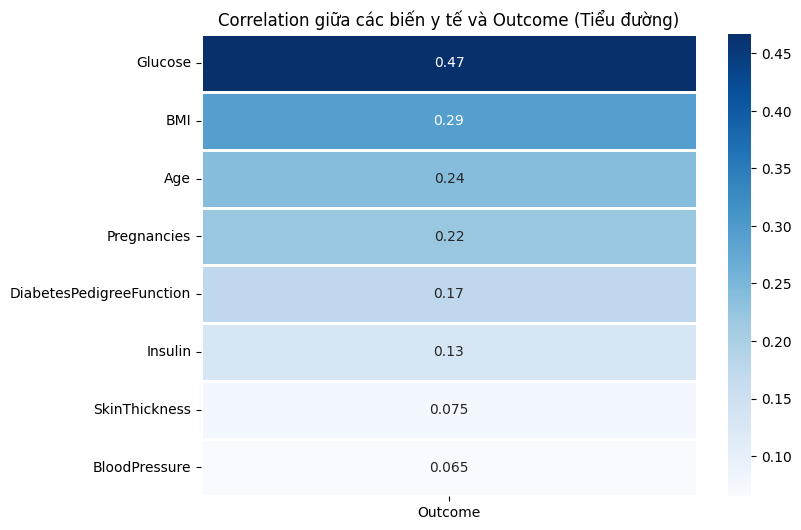

In [9]:
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin',
           'BMI','DiabetesPedigreeFunction','Age','Outcome']

df_dataset = pd.read_csv('./pima-indians-diabetes.csv', names=columns)
# Tính correlation
diabetes_corr = df_dataset.corr()

outcome_corr = diabetes_corr[['Outcome']] # Lấy cột outcome
outcome_corr = outcome_corr.drop('Outcome')  # bỏ hàng outcome

# Sorted
outcome_corr_sorted = outcome_corr.sort_values('Outcome', ascending=False)

# Heatmap
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(data=outcome_corr_sorted, cmap='Blues', linecolor='white', linewidths=1, annot=True);

plt.title('Correlation giữa các biến y tế và Outcome (Tiểu đường)');

##### Kết luận

- `Glucose` có tương quan trung bình (0.47) → quan trọng nhất.
- `BMI, Age, Pregnancies, DiabetesPedigreeFunction` → tương quan yếu (0.17–0.29).
- `Insulin, SkinThickness, BloodPressure` → gần như không liên quan (<0.13). <br>
=> Như vậy, Glucose là yếu tố dự báo chính, các biến khác chỉ bổ sung.

#### 2. Phân tích theo đơn biến

##### Biểu đồ

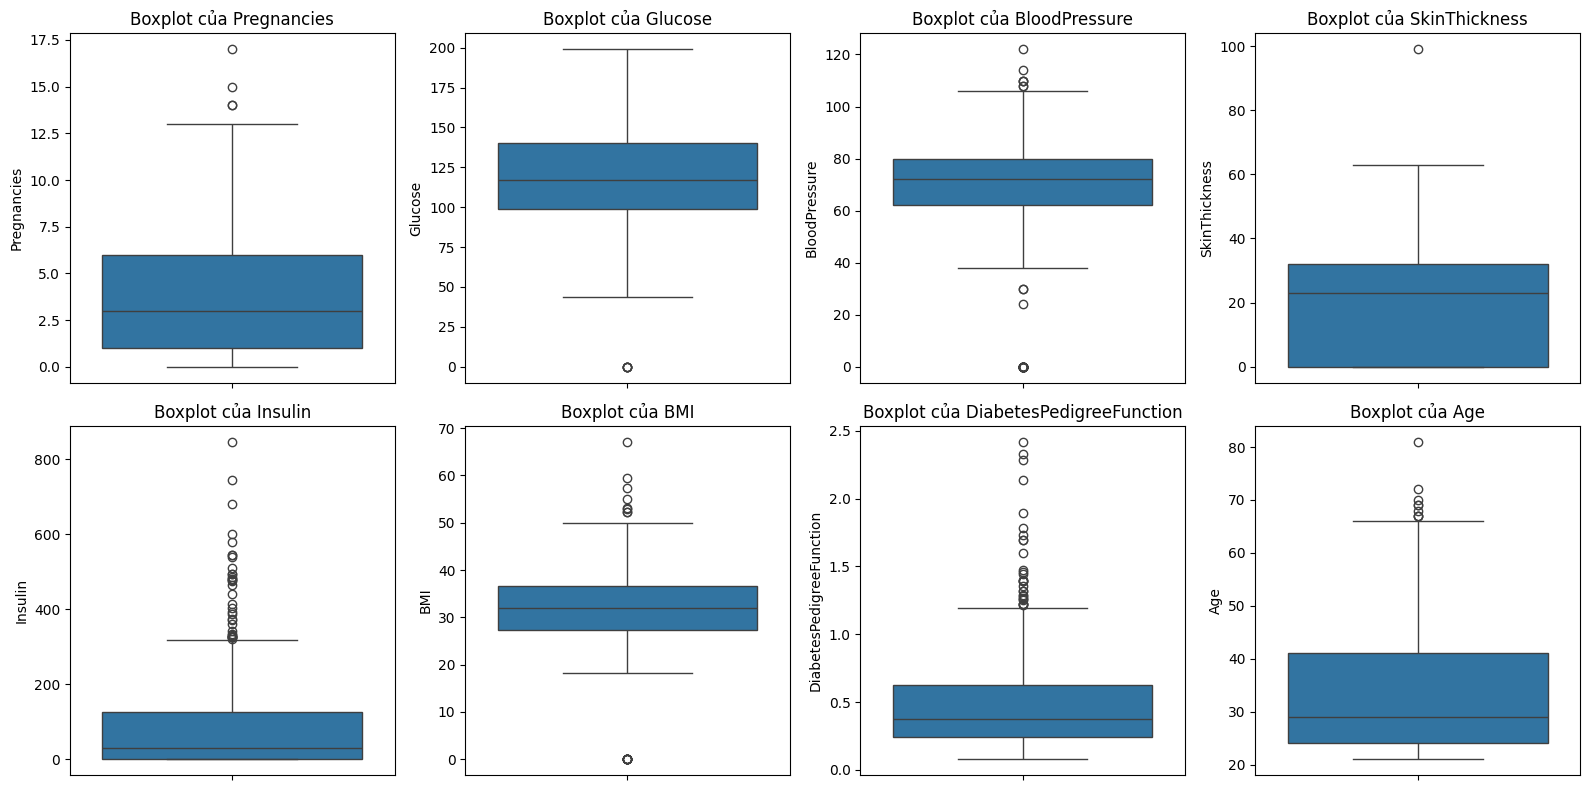

Pregnancies: Median = 3.00, IQR = 5.00, Outliers = 4
Glucose: Median = 117.00, IQR = 41.25, Outliers = 5
BloodPressure: Median = 72.00, IQR = 18.00, Outliers = 45
SkinThickness: Median = 23.00, IQR = 32.00, Outliers = 1
Insulin: Median = 30.50, IQR = 127.25, Outliers = 34
BMI: Median = 32.00, IQR = 9.30, Outliers = 19
DiabetesPedigreeFunction: Median = 0.37, IQR = 0.38, Outliers = 29
Age: Median = 29.00, IQR = 17.00, Outliers = 9


In [11]:
# Boxplot cho từng biến để tính Median, IQR, và outlier
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(columns[:-1]):
    sns.boxplot(y=df_dataset[col], ax=axes[i])
    axes[i].set_title(f'Boxplot của {col}')

plt.tight_layout()
plt.show()

# Tính Median và IQR cho từng biến
for col in columns[:-1]:
    median = df_dataset[col].median()
    iqr = df_dataset[col].quantile(0.75) - df_dataset[col].quantile(0.25)
    q1 = df_dataset[col].quantile(0.25)
    q3 = df_dataset[col].quantile(0.75)
    outliers = ((df_dataset[col] < q1 - 1.5 * iqr) | (df_dataset[col] > q3 + 1.5 * iqr)).sum()
    print(f'{col}: Median = {median:.2f}, IQR = {iqr:.2f}, Outliers = {outliers}')

##### Kết luận

- Đa số phụ nữ trong bộ dữ liệu có khoảng 3 lần mang thai, tuổi trung vị 29 (9 cá nhân cao tuổi khác biệt).

- Glucose và BMI tập trung quanh mức cao (Glucose ~117, BMI ~32 → nhiều người ở mức thừa cân, béo phì so với chuẩn (Glucose < 100, BMI < 30)).

- BloodPressure, DiabetesPedigreeFunction và Insulin lại có khá nhiều giá trị bất thường (outlier), dữ liệu hơi lộn xộn.


#### 3. Phân tích tương quan giữa các biến (Correlation Analysis)

=== Ma trận tương quan giữa các biến ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


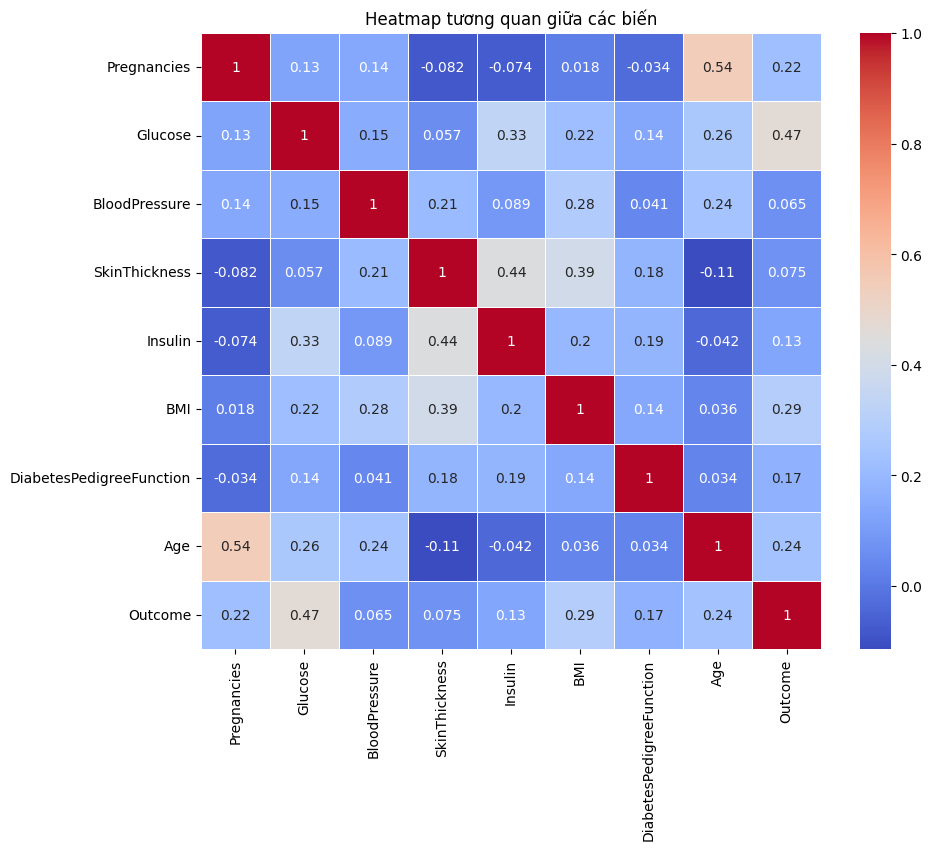

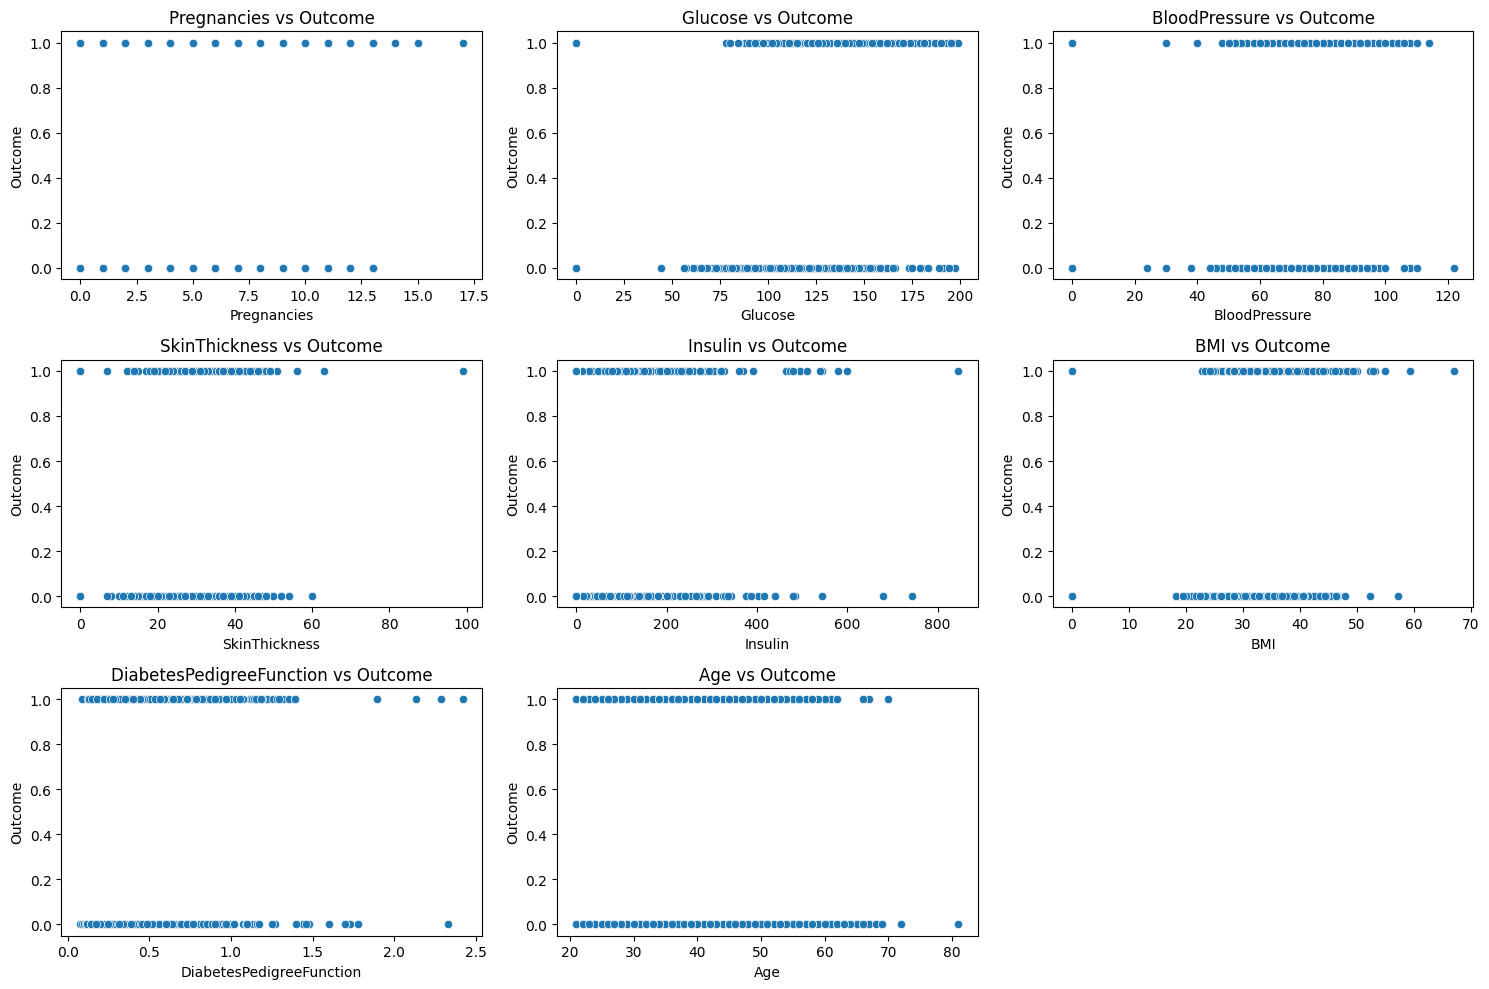

In [8]:
# Tính ma trận tương quan
corr_matrix = df_dataset.corr()

# Hiển thị ma trận tương quan
print("=== Ma trận tương quan giữa các biến ===")
display(corr_matrix)

# Vẽ heatmap trực quan
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Heatmap tương quan giữa các biến")
plt.show()

# Vẽ scatter plot giữa từng biến độc lập với Outcome
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=df_dataset[col], y=df_dataset['Outcome'])
    plt.title(f'{col} vs Outcome')
plt.tight_layout()
plt.show()

##### Nhận xét
Biểu đồ tương quan (Correlation Heatmap):
- Các biến như Glucose, BMI, Age, và Pregnancies thể hiện mối tương quan tương đối cao với biến Outcome (kết quả mắc bệnh tiểu đường).
- Trong đó, Glucose có hệ số tương quan dương mạnh nhất với Outcome → giá trị Glucose cao thường gắn với khả năng mắc bệnh cao hơn.
- Các biến như Insulin, SkinThickness, hay BloodPressure có tương quan yếu hơn → ít ảnh hưởng trực tiếp đến kết quả phân loại.
- Nhìn chung, ma trận tương quan cho thấy một số đặc trưng chính đóng vai trò quan trọng trong dự đoán tiểu đường, trong khi một số biến khác có thể cần xem xét thêm về khả năng loại bỏ hoặc chuẩn hóa.

Biểu đồ phân tán (Scatter Plot):
- Ở các scatter plot giữa từng biến và Outcome, ta thấy rõ ràng rằng:
- Glucose và BMI có xu hướng tăng khi Outcome = 1 (người mắc bệnh).
- Tuổi (Age) và số lần mang thai (Pregnancies) cũng cho thấy mức tăng dần với xác suất mắc bệnh cao hơn.
- Một số biến khác như BloodPressure hay SkinThickness có sự phân bố chồng lấn giữa hai nhóm (0 và 1), nên mức phân biệt thấp.
- Như vậy, dữ liệu thể hiện một xu hướng rõ ràng ở một số biến chính, có thể sử dụng để xây dựng mô hình học máy.

Đánh giá tổng quan:
- Dữ liệu không có phân bố tuyến tính hoàn toàn, nhưng vẫn có các đặc trưng nổi bật và xu hướng hợp lý.
- Một vài biến có thể chứa giá trị bằng 0 bất thường (như Insulin, SkinThickness) → cần xử lý trước khi huấn luyện mô hình (ví dụ thay thế bằng giá trị trung bình hoặc dùng kỹ thuật imputation).

#### 4. Trực quan hóa phân bố dữ liệu (Data Distribution Visualization)

<Figure size 1500x1000 with 0 Axes>

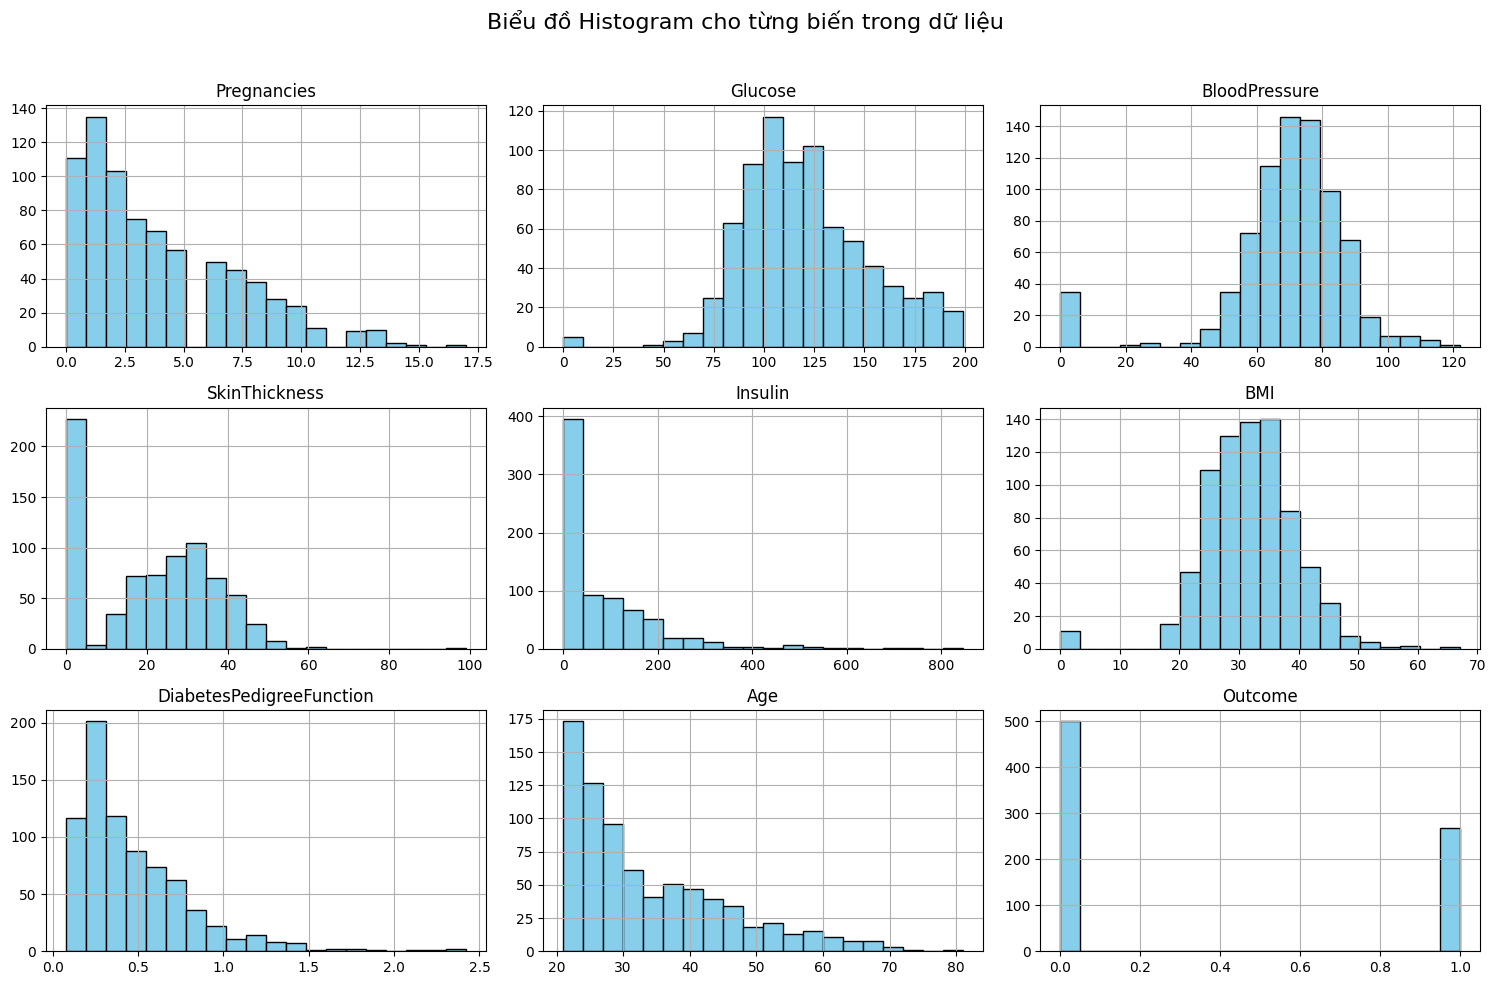

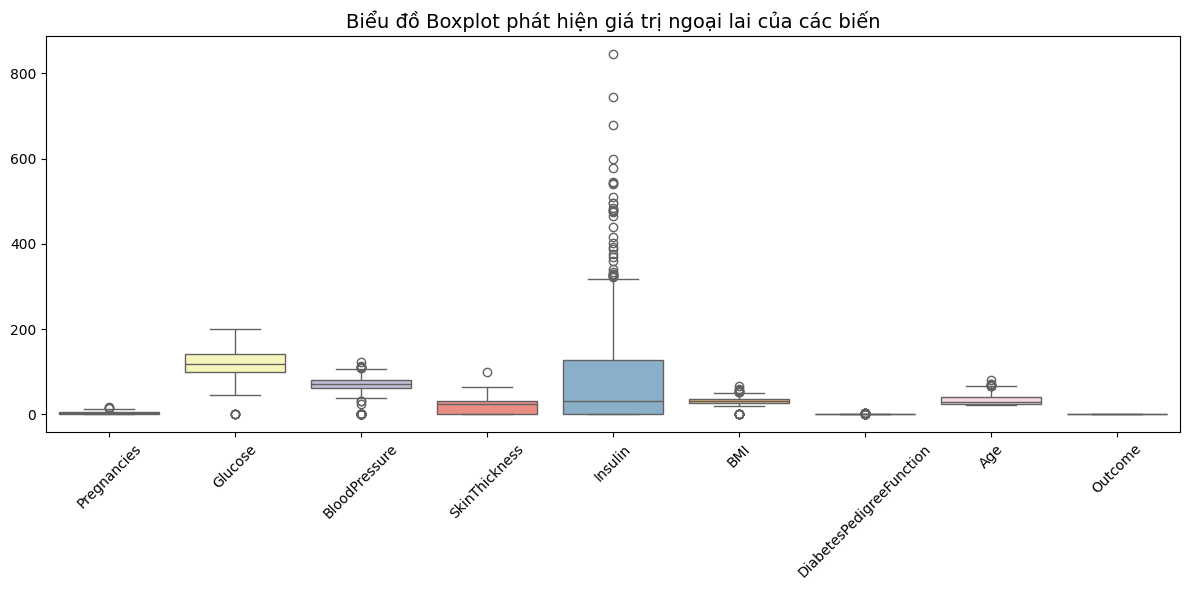

In [9]:
# Biểu đồ Histogram cho từng biến
plt.figure(figsize=(15, 10))
df_dataset.hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Biểu đồ Histogram cho từng biến trong dữ liệu", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Biểu đồ Boxplot để phát hiện giá trị ngoại lai
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_dataset, palette="Set3")
plt.title("Biểu đồ Boxplot phát hiện giá trị ngoại lai của các biến", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Nhận xét
Biểu đồ Histogram:
- Đa số các biến có phân bố lệch phải (right-skewed), nghĩa là phần lớn giá trị tập trung ở mức thấp, chỉ một số ít có giá trị rất cao.
- Biến Glucose có dạng gần giống phân bố chuẩn, tuy nhiên vẫn có một số giá trị thấp bất thường (các trường hợp bằng 0).
- Biến BMI cũng cho thấy dạng phân bố chuẩn rõ ràng, tập trung quanh giá trị trung bình khoảng 30.
- Các biến như Insulin và SkinThickness có rất nhiều giá trị bằng 0 → biểu hiện khả năng thiếu dữ liệu thực nghiệm (missing hoặc không đo được).
Nhìn chung, histogram giúp nhận thấy dữ liệu không hoàn toàn chuẩn, và có sự lệch phân bố đáng kể ở một số đặc trưng.

Biểu đồ Boxplot:
- Biểu đồ hộp (boxplot) chỉ ra sự tồn tại của nhiều giá trị ngoại lai (outliers) ở các biến như Insulin, SkinThickness, Glucose và BMI.
- Đặc biệt, Insulin có rất nhiều điểm vượt xa phần râu trên của hộp, cho thấy sự biến thiên rất lớn và có thể gây ảnh hưởng mạnh đến mô hình huấn luyện nếu không được xử lý.
- Ngược lại, các biến như BloodPressure và Age có phân bố khá ổn định, ít điểm ngoại lai hơn.
- Việc phát hiện sớm các giá trị ngoại lai giúp anh dễ dàng áp dụng các kỹ thuật như chuẩn hóa dữ liệu (normalization) hoặc cắt ngưỡng (clipping) trong bước tiền xử lý.

Đánh giá tổng quan:
- Phần trực quan hóa giúp nhận diện các vấn đề tiềm ẩn trong dữ liệu thực tế, bao gồm phân bố lệch và ngoại lai.
- Một số biến cần được làm sạch hoặc biến đổi (log transform, min-max scaling, xử lý zero-value) trước khi huấn luyện mô hình dự đoán.
- Kết quả này đóng vai trò quan trọng trong việc cải thiện chất lượng mô hình và đảm bảo tính ổn định của các thuật toán học máy sau này.


#### 4. Phân tích theo outcome

`Chú ý:`
**stat="density"** và **common_norm=False** để chuẩn hoá trục tung về mật độ. Như vậy số lượng người không ảnh hưởng nữa, giúp so sánh rõ ràng hình dạng phân bố giữa hai nhóm bệnh và không bệnh, tránh việc nhóm đông người lấn át nhóm ít người.

##### Biểu đồ

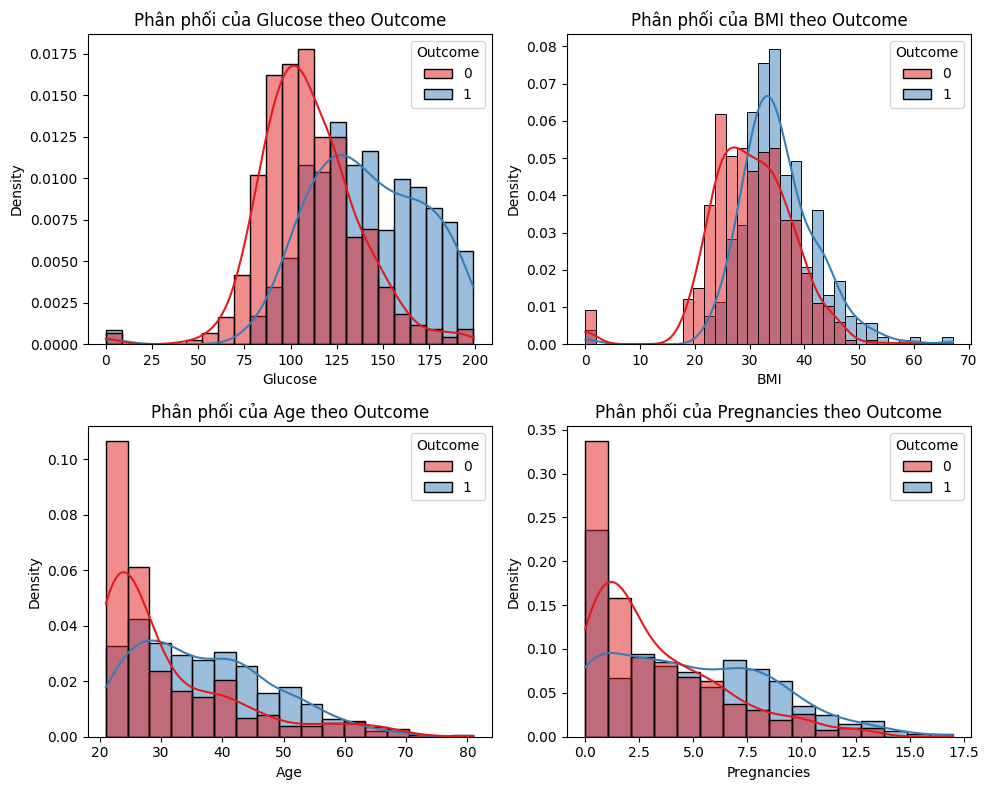

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Glucose', 'BMI','Age', 'Pregnancies']

# Vẽ grid X x Y
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten() # thành 1D

for i, var in enumerate(cols):
    sns.histplot(
        data=df_dataset, 
        x=var, 
        hue="Outcome", 
        kde=True, 
        stat="density",
        common_norm=False,
        ax=axes[i], # vẽ theo khung
        palette="Set1"
    )
    axes[i].set_title(f"Phân phối của {var} theo Outcome")

plt.tight_layout()

##### Nhận xét và Kết luận

`Không tiểu đường`: <br>
- **Glucose**: Phân bố tập trung chủ yếu khoảng 80 – 125 → tức là phần lớn người khỏe mạnh có mức đường huyết bình thường.
- **Age**: Nhóm không bệnh tập trung ở tuổi trẻ (20–25), càng lớn tuổi càng ít người không mắc (nguy cơ tăng dần).
- **BMI**: Vẫn có nhiều người BMI 30–40 nhưng Outcome = 0 → tức là ngoài béo phì còn có yếu tố khác mới có khả năng bệnh

`Mắc bệnh tiểu đường` (tiểu đường):
- **Glucose**: Phân bố lệch sang bên phải, nhiều người có Glucose ≥ 100, thậm chí cao hơn 150–200 → cho thấy đường huyết cao liên quan trực tiếp đến tiểu đường.
- **Age**: Phân bố đều ở nhiều độ tuổi.
- **BMI**
    - BMI < 25 (bình thường hoặc gầy): đa phần không mắc tiểu đường.
    - BMI 25–30 (thừa cân): bắt đầu thấy nhóm mắc tăng lên.
    - BMI 30–40 (béo phì): số ca mắc vượt trội hơn hẳn so với nhóm không mắc → nghĩa là béo phì là yếu tố nguy cơ mạnh.
- **Pregnancy**: Người có từ 6–12 lần mang thai có xu hướng mắc tiểu đường nhiều hơn so với không mắc

#### 5. Phân tích tỷ lệ mắc bệnh theo tuổi, số lần mang thai

##### Biểu đồ theo tuổi

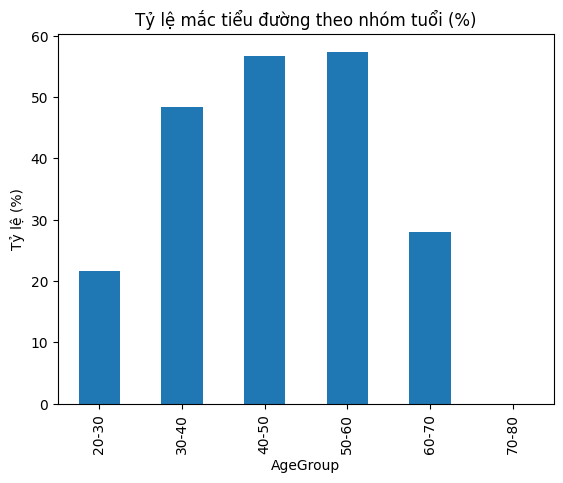

In [12]:
df_dataset['AgeGroup'] = pd.cut(df_dataset['Age'], bins=[20, 30, 40, 50, 60, 70, 80], labels=['20-30', '30-40', '40-50', '50-60', '60-70', '70-80'])
age_group_rate = df_dataset.groupby('AgeGroup', observed=True)['Outcome'].mean() * 100
age_group_rate.plot(kind='bar')
plt.title('Tỷ lệ mắc tiểu đường theo nhóm tuổi (%)')
plt.ylabel('Tỷ lệ (%)');

##### Biểu đồ theo số lần mang thai

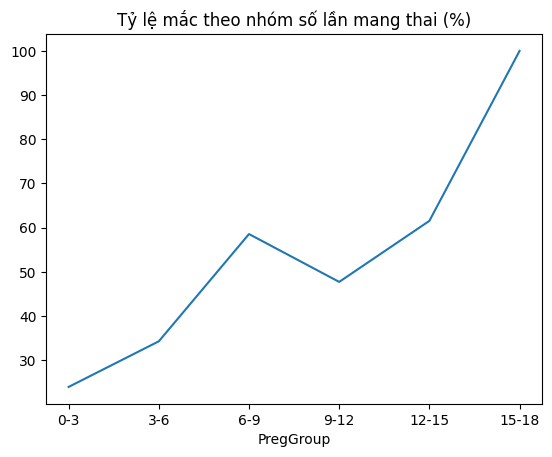

In [13]:
df_dataset['PregGroup'] = pd.cut(df_dataset['Pregnancies'], bins=[0, 3, 6, 9, 12, 15, 18], labels=['0-3', '3-6', '6-9', '9-12', '12-15', '15-18'])

preg_rate = df_dataset.groupby('PregGroup', observed=True)['Outcome'].mean() * 100
preg_rate.plot(kind='line')
plt.title('Tỷ lệ mắc theo nhóm số lần mang thai (%)');

##### Kết luận

Tuổi > 40 và mang thai > 6 có tỷ lệ cao hơn

#### 6. Phân tích các trường hợp bất thường (BMI > 30 và Glucose trên (200mg/dl))

`Tại sao là 200ml và BMI > 30`: <br>
dựa vào Paper 1 
- Firgure 1. Giá trị glucose máu ngẫu nhiên trong chẩn đoán đái tháo đường trang 58 paper 1

- Định nghĩa central obesity trang 33 Paper 1 
```html
(Central obesity (males: waist to hip ratio > 0.90; females:
waist to hip ratio > 0.85) and/or BMI > 30 kg m–2)
```

##### Biểu đồ

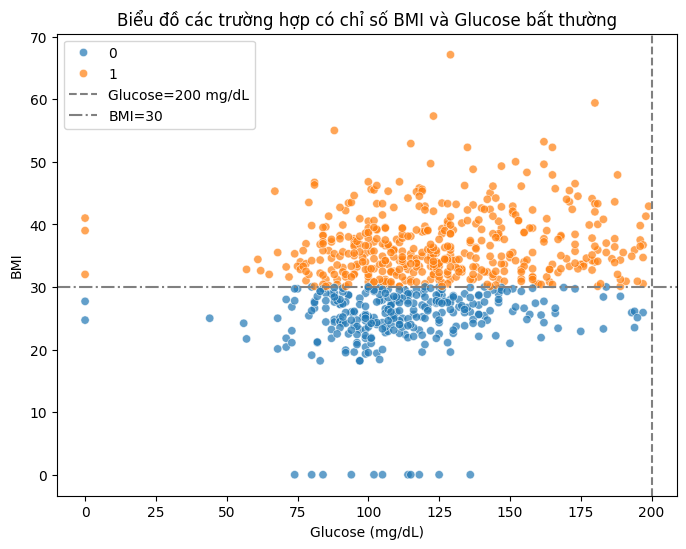

In [ ]:
df_dataset['HighRisk'] = ((df_dataset['Glucose'] > 200) | (df_dataset['BMI'] >   30)).astype(int)

# Scatter plot Glucose vs BMI
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_dataset,
    x='Glucose',
    y='BMI',
    hue='HighRisk',       # 1 = giả định mắc bệnh, 0 = không
    alpha=0.7
)
plt.axvline(200, color='gray', linestyle='--', label='Glucose=200 mg/dL')
plt.axhline(30, color='gray', linestyle='-.', label='BMI=30')
plt.xlabel('Glucose (mg/dL)')
plt.ylabel('BMI')
plt.title('Biểu đồ các trường hợp có chỉ số BMI và Glucose bất thường')
plt.legend();

##### Kết luận

Mặc dù có rất nhiều phụ nữ vượt ngưỡng BMI > 30 nhưng không ai có mức glucose vượt 200 mg/dL sau khi OGTT